> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** the generic data-manipulation toolkit, taught before it's needed for hydrography/sound-speed/combining: slicing and subsetting a time series, averaging/resampling, interpolating, and the mechanics of `xr.corr` on two already-available variables (e.g. TEMP vs PSAL) -- SVEL doesn't exist yet at this point in the series, so the correlation example here should use raw/QC'd variables, not sound speed.

**To do:** narrative still needs writing throughout (all the `- ` placeholders). The "A note on `TIME`" section below is a first draft in my voice -- rewrite it in yours. The "xarray resampling" subsection is still an empty heading.

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Slicing, averaging, interpolating, and correlating

- Slicing and subsetting a time series
- Averaging and resampling
- Interpolating
- Correlating two time series

In [1]:
import xarray as xr
from kval.data import moored
from matplotlib import pyplot as plt
import pandas as pd
%matplotlib widget

In [2]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc')

In [3]:
moored.plot(ds)

### A note on `TIME`

Before we start slicing, a word about how time is stored -- this matters for everything below.

In the file, `TIME` is not a date. It is a plain number: a count of time units from a fixed reference point, with the reference recorded in the variable's `units` attribute. Have a look:

In [4]:
ds.TIME

<xarray.DataArray 'TIME' (TIME: 23648)> Size: 189kB
array([18940.791661, 18940.798606, 18940.80555 , ..., 19105.568363,
       19105.575307, 19105.582251], shape=(23648,))
Coordinates:
  * TIME       (TIME) float64 189kB 1.894e+04 1.894e+04 ... 1.911e+04 1.911e+04
    LATITUDE   float32 4B ...
    LONGITUDE  float32 4B ...
Attributes:
    _FillValue:  nan
    units:       days since 1970-01-01
    calendar:    standard

This is the NetCDF/CF convention, and it is what `moored.load_nc` gives us by default. It is a good way to *store* time -- unambiguous, compact, and portable across languages -- but an awkward way to *work* with it. We can't ask for "the first week of February" using a number of days since 1970.

`xarray` understands the convention and can decode it into `datetime64` objects. `kval` wraps this in two functions that convert in either direction:

- `moored.time_as_datetime(ds)` -- number → `datetime64`
- `moored.time_as_float(ds)` -- `datetime64` → number

Each is a no-op if the data is already in the target form, so it is safe to call either one without checking first. `time_as_datetime` also remembers the original units, so converting back gives you exactly what you started with.

> **You often don't need to do this yourself.** `kval`'s own functions convert internally and hand back whatever form you gave them -- `moored.chop_by_time(ds, end_time = '2022-04-17 14:00')` in notebook 4 worked on numeric `TIME` for this reason. It is plain `xarray` indexing, like the `sel` calls below, that needs real datetimes.

Let's convert, so the rest of this notebook can address time by date:

In [5]:
ds = moored.time_as_datetime(ds)
ds.TIME

<xarray.DataArray 'TIME' (TIME: 23648)> Size: 189kB
array(['2021-11-09T18:59:59.529706240', '2021-11-09T19:09:59.525786624',
       '2021-11-09T19:19:59.521867776', ..., '2022-04-23T13:38:26.536918784',
       '2022-04-23T13:48:26.532999936', '2022-04-23T13:58:26.529080320'],
      shape=(23648,), dtype='datetime64[ns]')
Coordinates:
  * TIME       (TIME) datetime64[ns] 189kB 2021-11-09T18:59:59.529706240 ... ...
    LATITUDE   float32 4B ...
    LONGITUDE  float32 4B ...

### Slicing and subsetting

Xarray is built around the concept of *labelled coordinates* - i.e. each variable is associated with a particular set of dimensions. 

This makes it very easy to ..

#### Select by coordinate value 

To select data at a particular *value* along a dimension, use `sel`. Because `TIME` is a datetime coordinate, we can address it with a date string.

`method = 'nearest'` tells `xarray` to give us the closest available sample rather than requiring an exact match.



#### Example: *What was the temperature on Feb 01 at 21:00?*

To answer this, let's select the sample nearest to 21:00 on Feb 1st 2022:

In [6]:
ds_feb_01 = ds.sel(TIME = '2022-02-01 21:00', method = 'nearest')

.. and  print the result:

In [7]:
print(f'Temperature on {ds_feb_01.TIME.values} was {ds_feb_01.TEMP.values:.3f}°C')

Temperature on 2022-02-01T20:59:12.077048064 was 2.654°C


We can also select a **range** instead of just particular points, using what Python calls a `slice`:

> **Note:** unlike the single-point selection above, we don't pass `method` here. `xarray` does not accept a `method` argument together with a slice -- it raises `NotImplementedError: cannot use "method" argument if any indexers are slice objects`. A slice doesn't need one: the end points are interpreted as bounds, not as values to be matched.

#### Example: *What was the average salinity measured in the first half of March?*

Let's select all points within a *range* of times: 

In [8]:
time_slice = slice('2022-03-01', '2022-03-15')
ds_half_march = ds.sel(TIME = time_slice)

In [9]:
moored.plot(ds_half_march)

In [10]:
ds_half_march_mean = ds_half_march.PSAL.mean(dim='TIME').values
print(f'Mean practical salinity from all measurements from March 1th through 15th: {ds_half_march_mean:.3f}')

Mean practical salinity from all measurements from March 1th through 15th: 34.869


> ***Note*** this is an average of all measurements collected within this range. In many cases you might want a true time-weighted mean.

#### Select by index

To select a particular index of a dimension, use the function `isel`.

E.g. to select only the 1000th index along the `TIME` dimension: 

In [11]:
ds_ind1000 = ds.isel(TIME = 1000)

..and likewise we can select a range of points using a slice:

In [12]:
slice_index = slice(1000, 1110)
ds_ind1000_1110 = ds.isel(TIME = slice_index)

### Averaging and resampling

- 

In [13]:
ds_avgd = moored.time_average(ds, '12h')

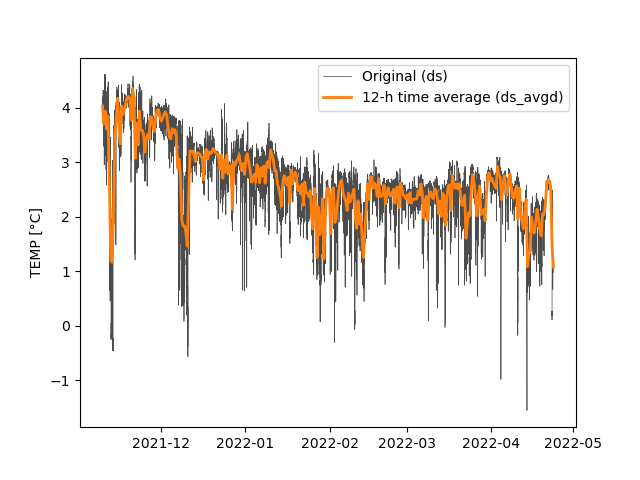

In [14]:
fig, ax = plt.subplots()
ax.plot(ds.TIME, ds.TEMP, label = 'Original (ds)', color = 'k', alpha = 0.7, lw = 0.5)
ax.plot(ds_avgd.TIME, ds_avgd.TEMP, label = '12-h time average (ds_avgd)', color = 'tab:orange', lw = 2)
ax.set_ylabel('TEMP [°C]')
ax.legend()


#### xarray resampling

### Interpolating

### Interpolate across data gaps

In some cases, we may want to interpolate across points with no data - i.e. NaNs. To do this, use xarrays `interpolate_na`.

To illustrate, lets make a hole of empty data in our `PRES`:


In [15]:
ds_hole = moored.remove_points(ds, 'PRES', remove_inds = slice(10000, 13000)) 

.. this should set all points in `PRES` between indices 10000 and 13000 to NaN. Let's check with a quick plot:

Text(0, 0.5, 'dbar')

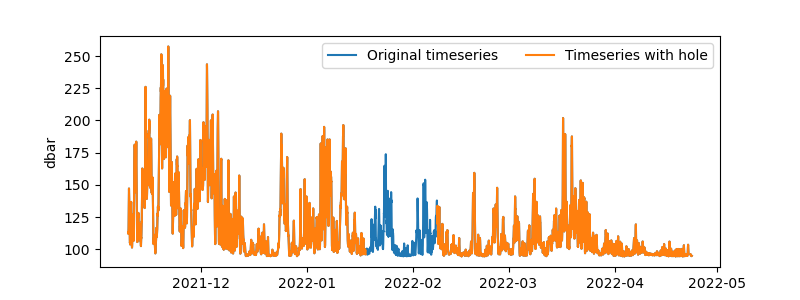

In [16]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.plot(ds.TIME, ds.PRES, label = 'Original timeseries')
ax.plot(ds_hole.TIME, ds_hole.PRES, label = 'Timeseries with hole')
ax.legend(ncol = 2)
ax.set_ylabel('dbar')

Now let's use `interpolate_na` to linearly interpolate over this hole: 

In [17]:
ds_hole_ip = ds_hole.interpolate_na(dim='TIME')

.. and another quick plot to check whether this worked:

Text(0, 0.5, 'dbar')

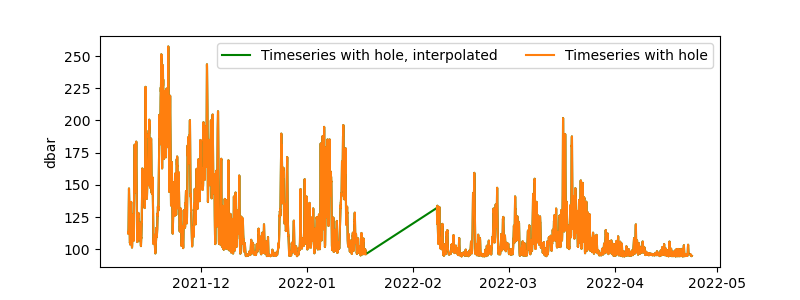

In [18]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.plot(ds_hole_ip.TIME, ds_hole_ip.PRES, 'g', label = 'Timeseries with hole, interpolated')
ax.plot(ds_hole.TIME, ds_hole.PRES, color = 'tab:orange', label = 'Timeseries with hole', )
ax.legend(ncol = 2)
ax.set_ylabel('dbar')

### Interpolate onto new points

Let's make a new time grid. For the sake of example, a 6-hourly grid spanning Dec 3rd to 6th 2021:

In [ ]:
TIME_new = pd.date_range('2021-12-03', '2021-12-06', freq='6h')

Now let's interpolate `ds` onto `TIME_new`:

In [ ]:
ds_ip_new = ds.interp(TIME=TIME_new)

In [ ]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.plot(ds.TIME, ds.PRES, color = 'k', lw = 0.5, label = 'Original (10-min sampling)')
ax.plot(ds_ip_new.TIME, ds_ip_new.PRES, 'o-', color = 'tab:red',
        label = 'Interpolated onto 6-hourly grid')
ax.set_xlim(TIME_new[0], TIME_new[-1])
ax.legend(ncol = 2)
ax.set_ylabel('dbar')

### Correlating two time series
For example, let's say we are interested in the correlation between `TEMP` and `PSAL` in our dataset: 

In [ ]:
timeseries_1 = ds.TEMP
timeseries_2 = ds.PSAL

In [ ]:
r = xr.corr(timeseries_1, timeseries_2)
print(f'r = {r:.3f}')

The two variables are positively and fairly strongly correlated.

> ✏️ **Review note** — this sentence used to quote the number directly (`p = 0.793`). I've taken the number out because outputs are cleared -- put it back once you re-run. I also renamed the variable from `p` to `r`: `p` reads as *p-value* to most people, and this is a correlation coefficient.

For more complex statistical analysis, look into the `stats` submodule of the [Scipy](https://scipy.org/) package - it is widely used for statistics and machine learning.